In [17]:
import torch
from torch.utils.data import DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import timesfm.timesfm_base as TFMbase
import timesfm.timesfm_torch as TFMtorch
import timesfm.data_loader as TFMDL
import timesfm.time_features as TFMtime
import timesfm.pytorch_patched_decoder as TFMmodel
import timesfm.custom_data_set as TFMdset

plt.rcParams['text.usetex'] = True
plt.rcParams.update({'font.size': 14})
plt.rcParams['text.latex.preamble'] = r'\usepackage{times}'

device = torch.device('cuda:0')

In [2]:
# batch size
batch_size = 64

# data
tcm = TFMbase.TimesFmHparams
tcm.per_core_batch_size = batch_size
tckpt = TFMbase.TimesFmCheckpoint(path='/home/sbose/timesfm/timesfm-1.0-200m-pytorch/torch_model.ckpt')
base = TFMtorch.TimesFmTorch(tcm,tckpt)

In [3]:
# get a dataloader

data = np.load('/lcrc/project/NEXTGENOPT/NREL_COMSTOCK_DATA/datasets/by_iso_uncompressed/Midwest.npy')

dataset_train, dataset_val, dataset_test, mean, std = TFMdset.get_data_and_generate_train_val_test_sets(
    data_array = data,
    split_ratios = [0.8,0.1,0.1],
    dataset_kwargs = {
        'num_bldg' : data.shape[0],
        'lookback' : 96,
        'lookahead' : 96,
        'normalize' : True,
        'dtype' : torch.float32,
        'context_len' : 512,
        'output_unpadded_inputs' : True
    }
)


In [22]:
# get dataloader
dl = DataLoader(dataset_train, batch_size = batch_size, shuffle=False)

# move model to device
base._model = base._model.to(device)

In [33]:
# forecast for first item in batch
for itm in dl:
    ts, paddings, freq, y, x_unpadded = itm
    ts, paddings, freq, y, x_unpadded = ts.to(device), paddings.to(device), freq.to(device), y.to(device), x_unpadded.to(device)
    w = base._model.decode(
        ts,
        paddings,
        freq,
        horizon_len = 96
    )
    break

# move model back to CPU
base._model = base._model.to('cpu')

# forecast using api
forecast_input = [
    x_unpadded[0,:].cpu().numpy()
]
freq_input = [0]
R = base.forecast(
    forecast_input,
    freq_input
)


Text(0, 0.5, 'Demand kWh')

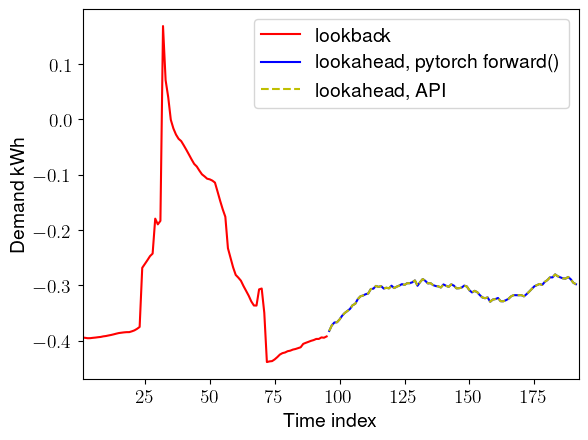

In [52]:
plt.plot(np.arange(96),x_unpadded[0].cpu().numpy(),'r',label='lookback')
plt.plot(np.arange(96,192),R[0][0,:96],'b',label='lookahead, pytorch forward()')
plt.plot(np.arange(96,192),w[0][0].detach().cpu().numpy(),'y--',label='lookahead, API')
plt.xlim(1,192)
plt.legend()
plt.xlabel('Time index')
plt.ylabel('Demand kWh')

In [43]:
R[0][0,-96:].shape

(96,)